## AirQualityUCI.csv
To predict Total Nitrogen Oxides (NOx).
Updated Oct 26, 2025
* validation_split=0.2 is used in .fit() instead of validation_data=(X_val..., y_val)
```
Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2,6;1360;150;11,9;1046;166;1056;113;1692;1268;13,6;48,9;0,7578;;
10/03/2004;19.00.00;2;1292;112;9,4;955;103;1174;92;1559;972;13,3;47,7;0,7255;;
...
11/03/2004;00.00.00;1,2;1185;31;3,6;690;62;1462;77;1333;733;11,3;56,8;0,7603;;

```
https://archive.ics.uci.edu/dataset/360/air+quality

In [ ]:
# import libraries
import pandas as pd
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

from google.colab import drive
drive.mount('/content/gdrive')

# load the dataset
file_path = '/content/gdrive/My Drive/DL_data/airQualityUCI/AirQualityUCI.csv'
data = pd.read_csv(file_path, delimiter=';')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# clean numeric columns
columns_to_clean = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH'] # origianl article did not include CO(GT)

# replace commas with dots and convert them to numeric
for col in columns_to_clean:
    data[col] = data[col].str.replace(',', '.')
    data[col] = pd.to_numeric(data[col], errors='coerce')

# drop the unnamed columns and any rows with missing values
data_cleaned = data.drop(columns=['Unnamed: 15', 'Unnamed: 16']).dropna()

# convert 'Date' and 'Time' to a single DateTime index <=== Not a colum!!!
data_cleaned['DateTime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H.%M.%S')
data_cleaned = data_cleaned.set_index('DateTime')

# drop the 'Date' and 'Time' columns
data_cleaned = data_cleaned.drop(columns=['Date', 'Time'])

# ensure all columns are numeric
data_cleaned = data_cleaned.apply(pd.to_numeric, errors='coerce')

# Replace -200 with
#data_cleaned = data_cleaned.replace(-200, np.nan).ffill() # forward fill, next valid value
# values with the average (the linearly calculated value) between the previous and next valid points.
data_cleaned = data_cleaned.replace(-200, np.nan).interpolate()

print(f"shape before drop NaN = {data_cleaned.shape}")
# drop any rows with NaN
data_cleaned = data_cleaned.dropna()
print(f"shape after drop NaN = {data_cleaned.shape}")

# split the data (80% train, 20% test)
train_size = int(len(data_cleaned) * 0.8)
train_data = data_cleaned[:train_size]
test_data = data_cleaned[train_size:]

# Split train_data into training and validation sets (80% train, 20% validation of the original train_data)
# Better way is to use validation_split=0.2 in .fit()
# train_val_size = int(len(train_data) * 0.8)
# train_data_split = train_data[:train_val_size]
# val_data = train_data[train_val_size:]

shape before drop NaN = (9357, 13)
shape after drop NaN = (9357, 13)


In [ ]:
print(train_data.head(10))
print(train_data.shape)
train_data.iloc[0]

                     CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
DateTime                                                                      
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0   
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0   
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0   
2004-03-10 21:00:00     2.2       1376.0      80.0       9.2          948.0   
2004-03-10 22:00:00     1.6       1272.0      51.0       6.5          836.0   
2004-03-10 23:00:00     1.2       1197.0      38.0       4.7          750.0   
2004-03-11 00:00:00     1.2       1185.0      31.0       3.6          690.0   
2004-03-11 01:00:00     1.0       1136.0      31.0       3.3          672.0   
2004-03-11 02:00:00     0.9       1094.0      24.0       2.3          609.0   
2004-03-11 03:00:00     0.6       1010.0      19.0       1.7          561.0   

                     NOx(GT)  PT08.S3(NOx)  NO2(GT)

,2004-03-10 18:00:00
CO(GT),2.6000
PT08.S1(CO),1360.0000
NMHC(GT),150.0000
C6H6(GT),11.9000
PT08.S2(NMHC),1046.0000
NOx(GT),166.0000
PT08.S3(NOx),1056.0000
NO2(GT),113.0000
PT08.S4(NO2),1692.0000
PT08.S5(O3),1268.0000


In [ ]:
#print(train_data.tail(10))
#print(test_data.head(10))
#print(test_data.tail(10))
print(test_data.shape)

(1872, 13)


## Prepare Time Series Data for Training and Testing

In [ ]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# data prep
def create_lagged_features(data, n_lags):
    lagged_data = data.copy()
    for i in range(1, n_lags + 1):
        lagged_data[f'NOx_lag_{i}'] = lagged_data['NOx(GT)'].shift(i)
    lagged_data = lagged_data.dropna()
    return lagged_data

n_lags = 3

# apply lagged feature generation to train, validation and test
train_data_lagged = create_lagged_features(train_data, n_lags)
test_data_lagged = create_lagged_features(test_data, n_lags)

# separate out X and y
X_train_all_features = train_data_lagged.drop(columns=['NOx(GT)']).values
y_train = train_data_lagged['NOx(GT)'].values
X_test_all_features = test_data_lagged.drop(columns=['NOx(GT)']).values
y_test = test_data_lagged['NOx(GT)'].values

print(f"train data shape = {X_train_all_features.shape}, when n_lags is {n_lags}")
print(f"test  data shape = {X_test_all_features.shape}, when n_lags is {n_lags}")

train data shape = (7482, 15), when n_lags is 3
test  data shape = (1869, 15), when n_lags is 3


In [ ]:
# reshape data for GRU n LSTM (samples, timesteps, features)
# The number of features per timestep should be the total number of features before adding lags
X_train_all_features_4m = X_train_all_features.reshape((X_train_all_features.shape[0],
                                                        n_lags,
                                                        X_train_all_features.shape[1] // n_lags))
print(f"X_train_all_features_4m shape = {X_train_all_features_4m.shape}")
X_test_all_features_4m = X_test_all_features.reshape((X_test_all_features.shape[0], n_lags, X_train_all_features.shape[1] // n_lags))
print(f"X_test_all_features_4m shape = {X_test_all_features_4m.shape}")

print(X_train_all_features_4m)

X_train_all_features_4m shape = (7482, 3, 5)
X_test_all_features_4m shape = (1869, 3, 5)
[[[2.200e+00 1.376e+03 8.000e+01 9.200e+00 9.480e+02]
  [1.092e+03 1.220e+02 1.584e+03 1.203e+03 1.100e+01]
  [6.000e+01 7.867e-01 1.310e+02 1.030e+02 1.660e+02]]

 [[1.600e+00 1.272e+03 5.100e+01 6.500e+00 8.360e+02]
  [1.205e+03 1.160e+02 1.490e+03 1.110e+03 1.120e+01]
  [5.960e+01 7.888e-01 1.720e+02 1.310e+02 1.030e+02]]

 [[1.200e+00 1.197e+03 3.800e+01 4.700e+00 7.500e+02]
  [1.337e+03 9.600e+01 1.393e+03 9.490e+02 1.120e+01]
  [5.920e+01 7.848e-01 1.310e+02 1.720e+02 1.310e+02]]

 ...

 [[8.000e-01 8.310e+02 2.750e+02 2.200e+00 6.020e+02]
  [1.123e+03 8.900e+01 8.240e+02 5.270e+02 1.110e+01]
  [3.340e+01 4.401e-01 1.380e+02 1.720e+02 2.360e+02]]

 [[1.000e+00 8.660e+02 2.750e+02 3.000e+00 6.520e+02]
  [1.060e+03 9.800e+01 8.570e+02 5.730e+02 1.190e+01]
  [3.080e+01 4.285e-01 1.210e+02 1.380e+02 1.720e+02]]

 [[8.000e-01 8.190e+02 2.750e+02 1.900e+00 5.760e+02]
  [1.142e+03 8.500e+01 8.090e+0

## Prediction with GRU

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Root Mean Squared Error (RMSE) for GRU (All Features): 89.67304575067375


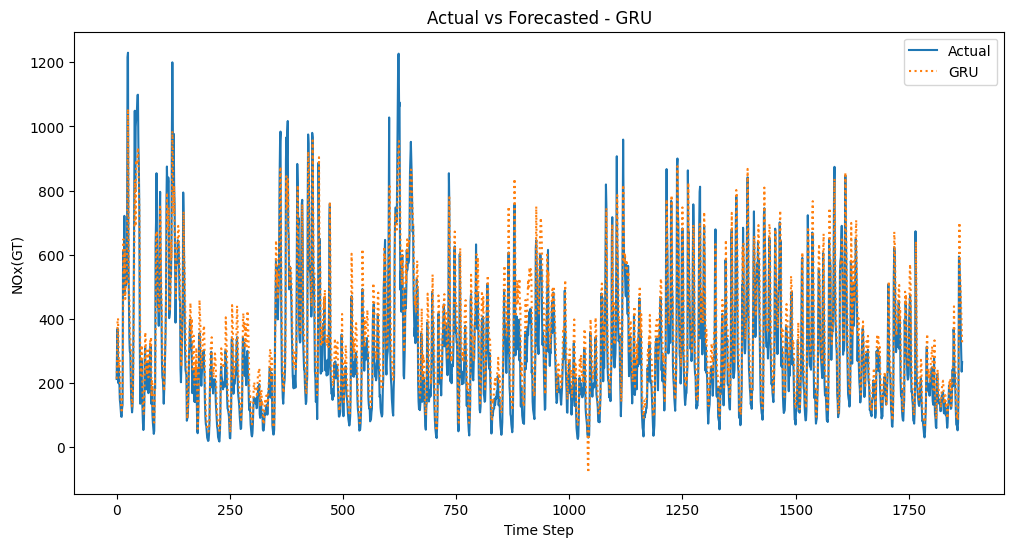

In [ ]:
# build GRU
model_gru_all_features = Sequential()
model_gru_all_features.add(GRU(60, activation='relu', input_shape=(n_lags, X_train_all_features_4m.shape[2])))
model_gru_all_features.add(Dense(1))  # Output layer predicting one value (NOx(GT))
model_gru_all_features.compile(optimizer='adam', loss='mse')

# add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# train
history_gru_all_features =
  model_gru_all_features.fit(X_train_all_features_4m,
                             y_train,
                             epochs=150,
                             batch_size=32,
                             #validation_data=(X_val_all_features-4m, y_val),
                             validation_split=0.2,
                             callbacks=[early_stopping],
                             verbose=0)

# forecast
y_pred_gru_all_features = model_gru_all_features.predict(X_test_all_features_4m)

# evaluate
rmse_gru_all_features = np.sqrt(mean_squared_error(y_test, y_pred_gru_all_features))
print(f'Root Mean Squared Error (RMSE) for GRU (All Features): {rmse_gru_all_features}')

# visualize
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_gru_all_features, label='GRU', linestyle=':')
plt.title('Actual vs Forecasted - GRU')
plt.xlabel('Time Step')
plt.ylabel('NOx(GT)')
plt.legend()
plt.show()

## Predict using LSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Root Mean Squared Error (RMSE): 86.70891446531002
RMSE calculated from m.evaluate: 86.70890991468956


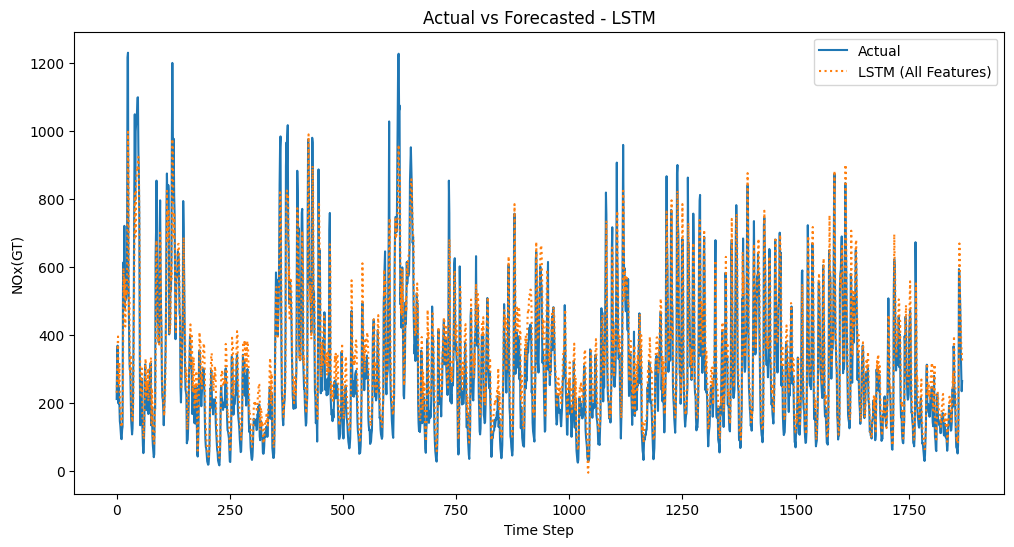

In [ ]:
# build the model
model_all_features = Sequential()
model_all_features.add(LSTM(50, activation='relu', input_shape=(n_lags, X_train_all_features_4m.shape[2]))) # 3, 5
model_all_features.add(Dense(1))
model_all_features.compile(optimizer='adam', loss='mse')

# add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# train
history_all_features = model_all_features.fit(X_train_all_features_4m,
                                              y_train, epochs=100,
                                              batch_size=32,
                                              #validation_data=(X_val_lstm_all_features, y_val),
                                              validation_split=0.2,
                                              callbacks=[early_stopping], verbose=0)

# forecast
y_pred_all_features = model_all_features.predict(X_test_all_features_4m)

# evaluate
rmse_all_features = np.sqrt(mean_squared_error(y_test, y_pred_all_features))
print(f'Root Mean Squared Error (RMSE): {rmse_all_features}')

loss = model_all_features.evaluate(X_test_all_features_4m, y_test, verbose=0)
print(f'RMSE calculated from m.evaluate: {np.sqrt(loss)}')

# visualize
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_all_features, label='LSTM (All Features)', linestyle=':')
plt.title('Actual vs Forecasted - LSTM')
plt.xlabel('Time Step')
plt.ylabel('NOx(GT)')
plt.legend()
plt.show()

## GRU 30 => 8 => 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Root Mean Squared Error (RMSE) for GRU (All Features): 89.71140550906374


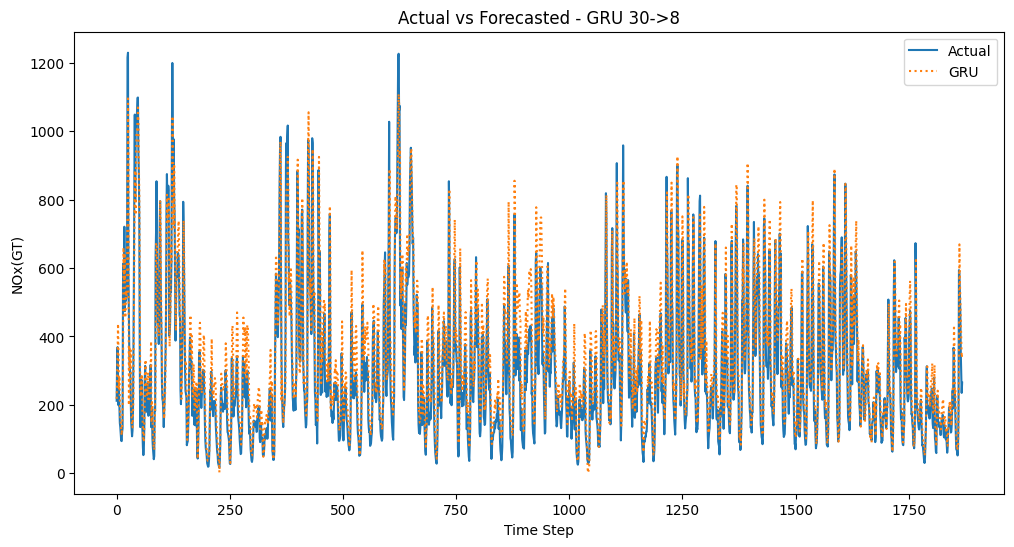

In [ ]:
model_gru_all_features = Sequential()
model_gru_all_features.add(GRU(30, activation='relu', input_shape=(n_lags, X_train_all_features_4m.shape[2])))
model_gru_all_features.add(Dense(8))
model_gru_all_features.add(Dense(1))  # Output layer predicting one value (NOx(GT))
model_gru_all_features.compile(optimizer='adam', loss='mse')

# add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# train
history_gru_all_features = model_gru_all_features.fit(X_train_all_features_4m,
                                                      y_train, epochs=150,
                                                      batch_size=32,
                                                      #validation_data=(X_test_gru_all_features, y_test),
                                                      validation_split=0.2,
                                                      callbacks=[early_stopping], verbose=0)

# forecast
y_pred_gru_all_features = model_gru_all_features.predict(X_test_all_features_4m)

# evaluate
rmse_gru_all_features = np.sqrt(mean_squared_error(y_test, y_pred_gru_all_features))
print(f'Root Mean Squared Error (RMSE) for GRU (All Features): {rmse_gru_all_features}')

# visualize
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_gru_all_features, label='GRU', linestyle=':')
plt.title('Actual vs Forecasted - GRU 30->8')
plt.xlabel('Time Step')
plt.ylabel('NOx(GT)')
plt.legend()
plt.show()

## Pandas Testing

In [ ]:
# dataframe shift() test
import pandas as pd

df = pd.DataFrame({'A': [1, 2, 3, 4], 'B': [5, 6, 7, 8], 'C': [9, 0, 1, 2]})
print(df)
# Shift the data down by 1 row
df_shifted_down = df.shift(1)
print(df_shifted_down)

   A  B  C
0  1  5  9
1  2  6  0
2  3  7  1
3  4  8  2
     A    B    C
0  NaN  NaN  NaN
1  1.0  5.0  9.0
2  2.0  6.0  0.0
3  3.0  7.0  1.0


In [ ]:
n = 2
df = pd.DataFrame({'A': [1, 2, 3, 4], 'B': [5, 6, 7, 8], 'C': [9, 0, 1, 2]})
for i in range(1, n + 1):
    df[f'lag_{i}'] = df['B'].shift(i)
df_shifted_down = df.shift(1)
print(df_shifted_down)

     A    B    C  lag_1  lag_2
0  NaN  NaN  NaN    NaN    NaN
1  1.0  5.0  9.0    NaN    NaN
2  2.0  6.0  0.0    5.0    NaN
3  3.0  7.0  1.0    6.0    5.0
